PHASE 7 — FINAL VARIABLE-RESOLUTION 2.5D GRID

Loaded Phase 6 output:
  Points:         123,389
  QT nodes:       45,119
  Leaf nodes:     31,737
  Internal nodes: 13,382
  Grid extent:    X=[-81.0, 80.5], Y=[-81.0, 79.5]
  Coarsest res:   0.5 m
  Max depth:      3

Level resolutions:
  Level 0: 50.00 cm
  Level 1: 25.00 cm
  Level 2: 12.50 cm
  Level 3: 6.25 cm

Final grid built in 20.5 ms
  Total final leaf cells: 31,737
  Final cell dtype fields: ['x_min', 'x_max', 'y_min', 'y_max', 'x_center', 'y_center', 'resolution', 'level', 'elevation', 'min_height', 'max_height', 'elevation_variance', 'semantic_class', 'semantic_confidence', 'occupancy', 'terrain_complexity', 'traversability', 'point_count', 'semantic_priority', 'height_range']
  Memory: 4587.0 KB
FINAL GRID VALIDATION
[PASS] No overlapping leaf cells detected (1,484,988 pair checks)
[PASS] Final cell count matches QT leaf count (31,737)
[PASS] Parent-child spatial containment (33,845 checks)
[PASS] All data ranges valid
[PASS

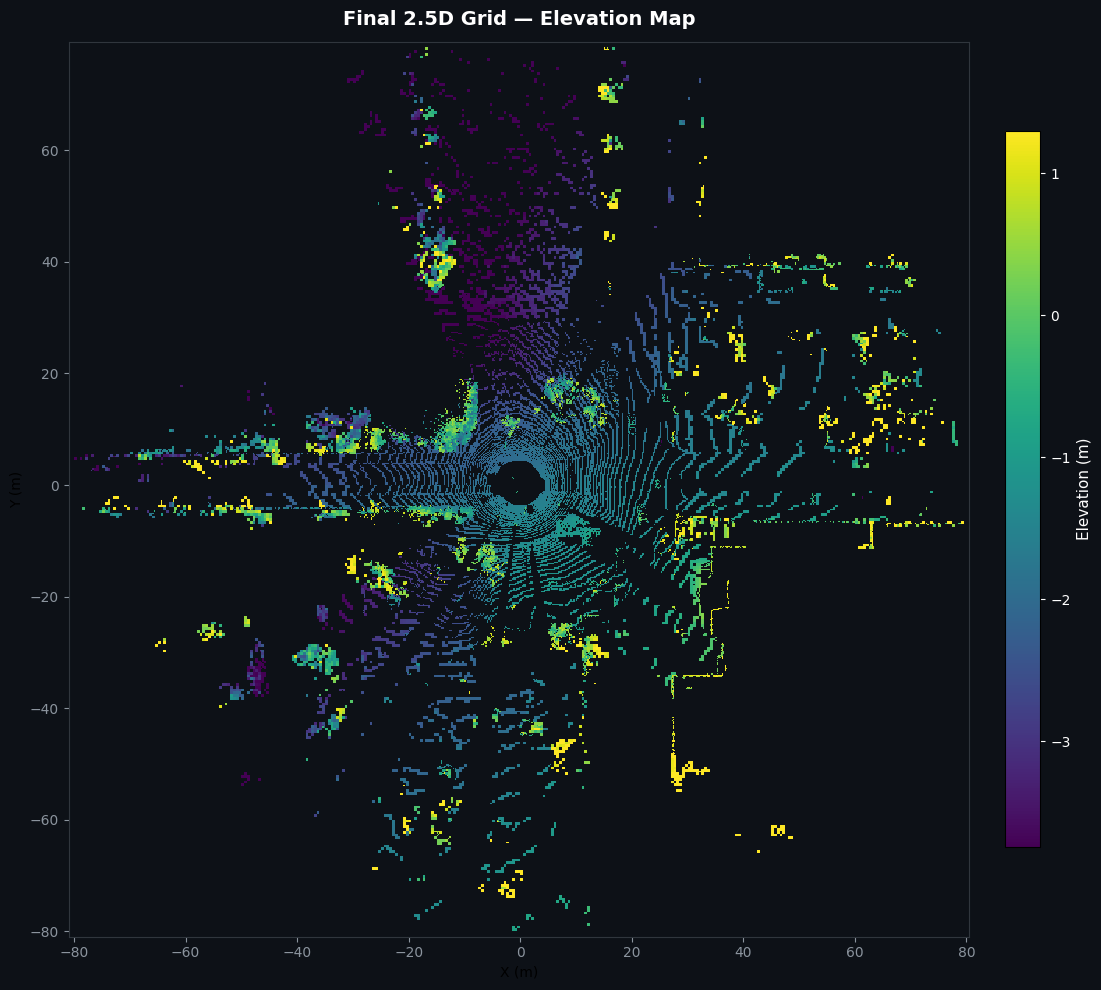

  Saved: vis_p7_01_elevation.png
Generating: Semantic map...


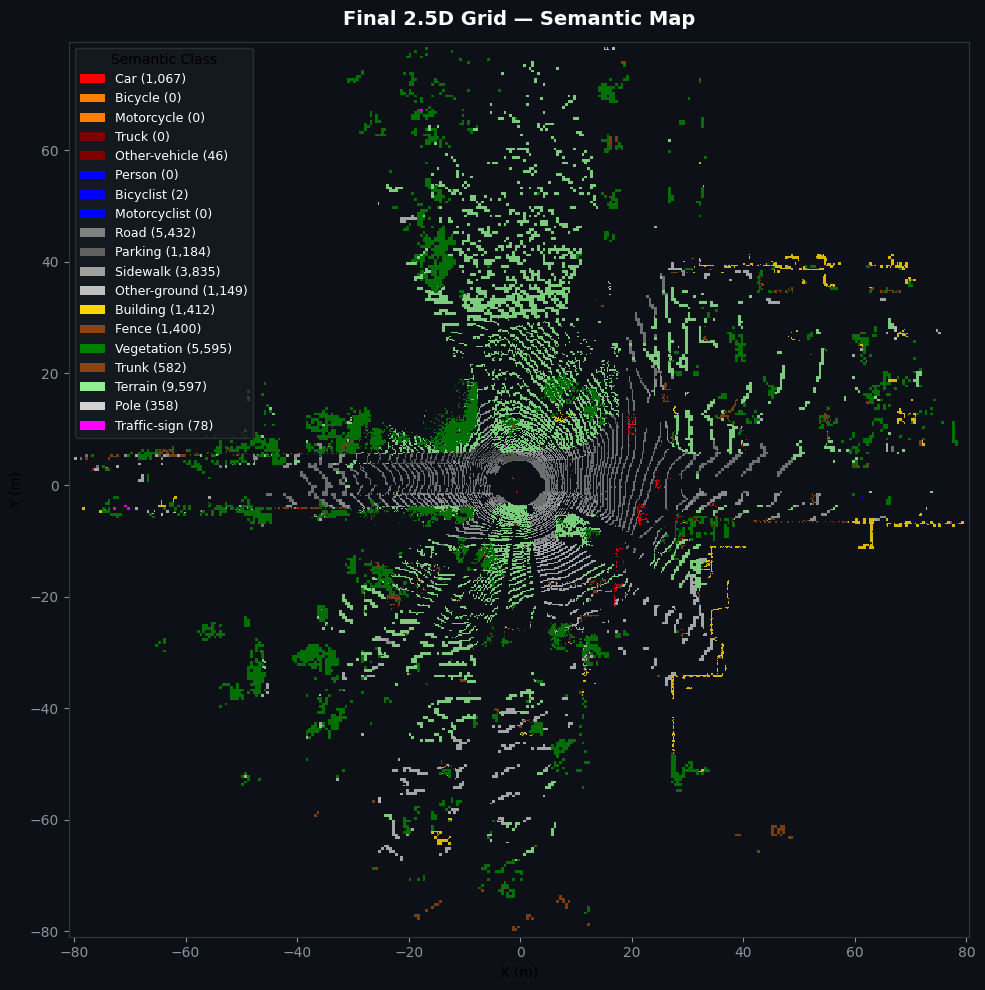

  Saved: vis_p7_02_semantic.png
Generating: Resolution map...


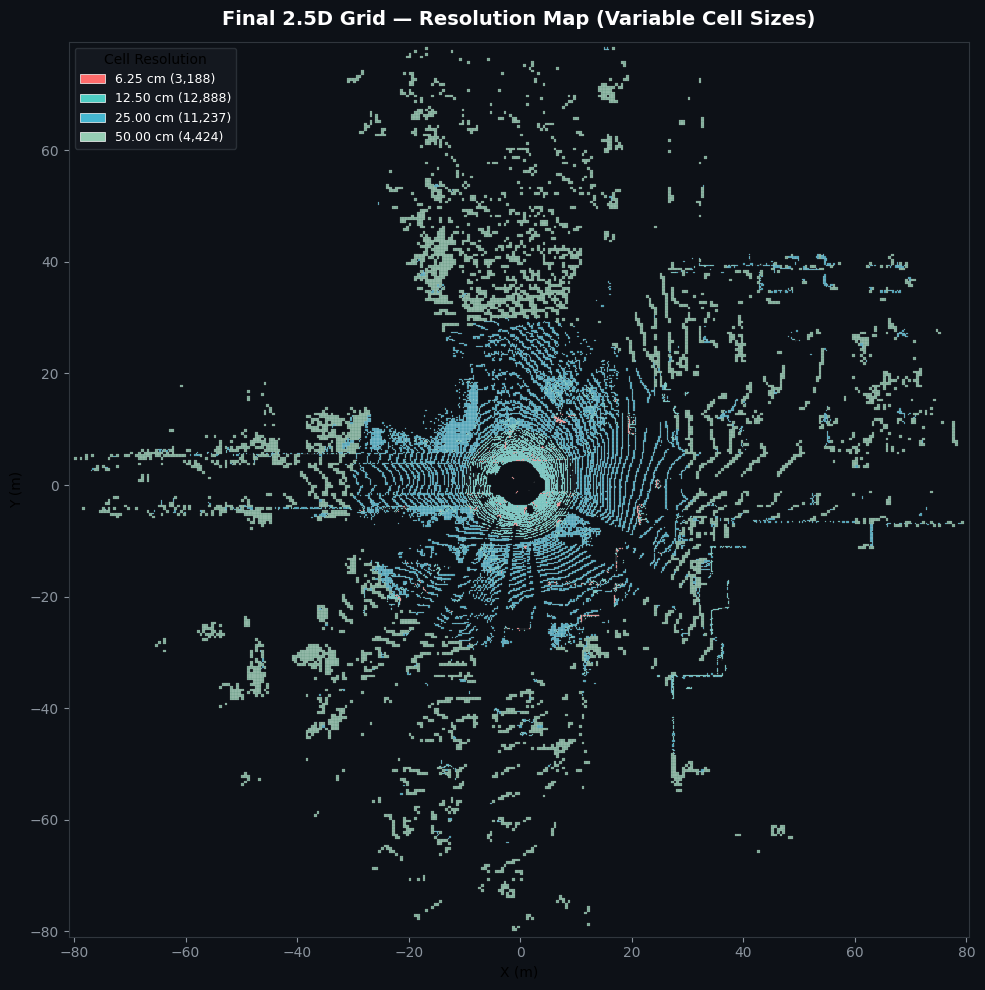

  Saved: vis_p7_03_resolution.png
Generating: Resolution detail view...


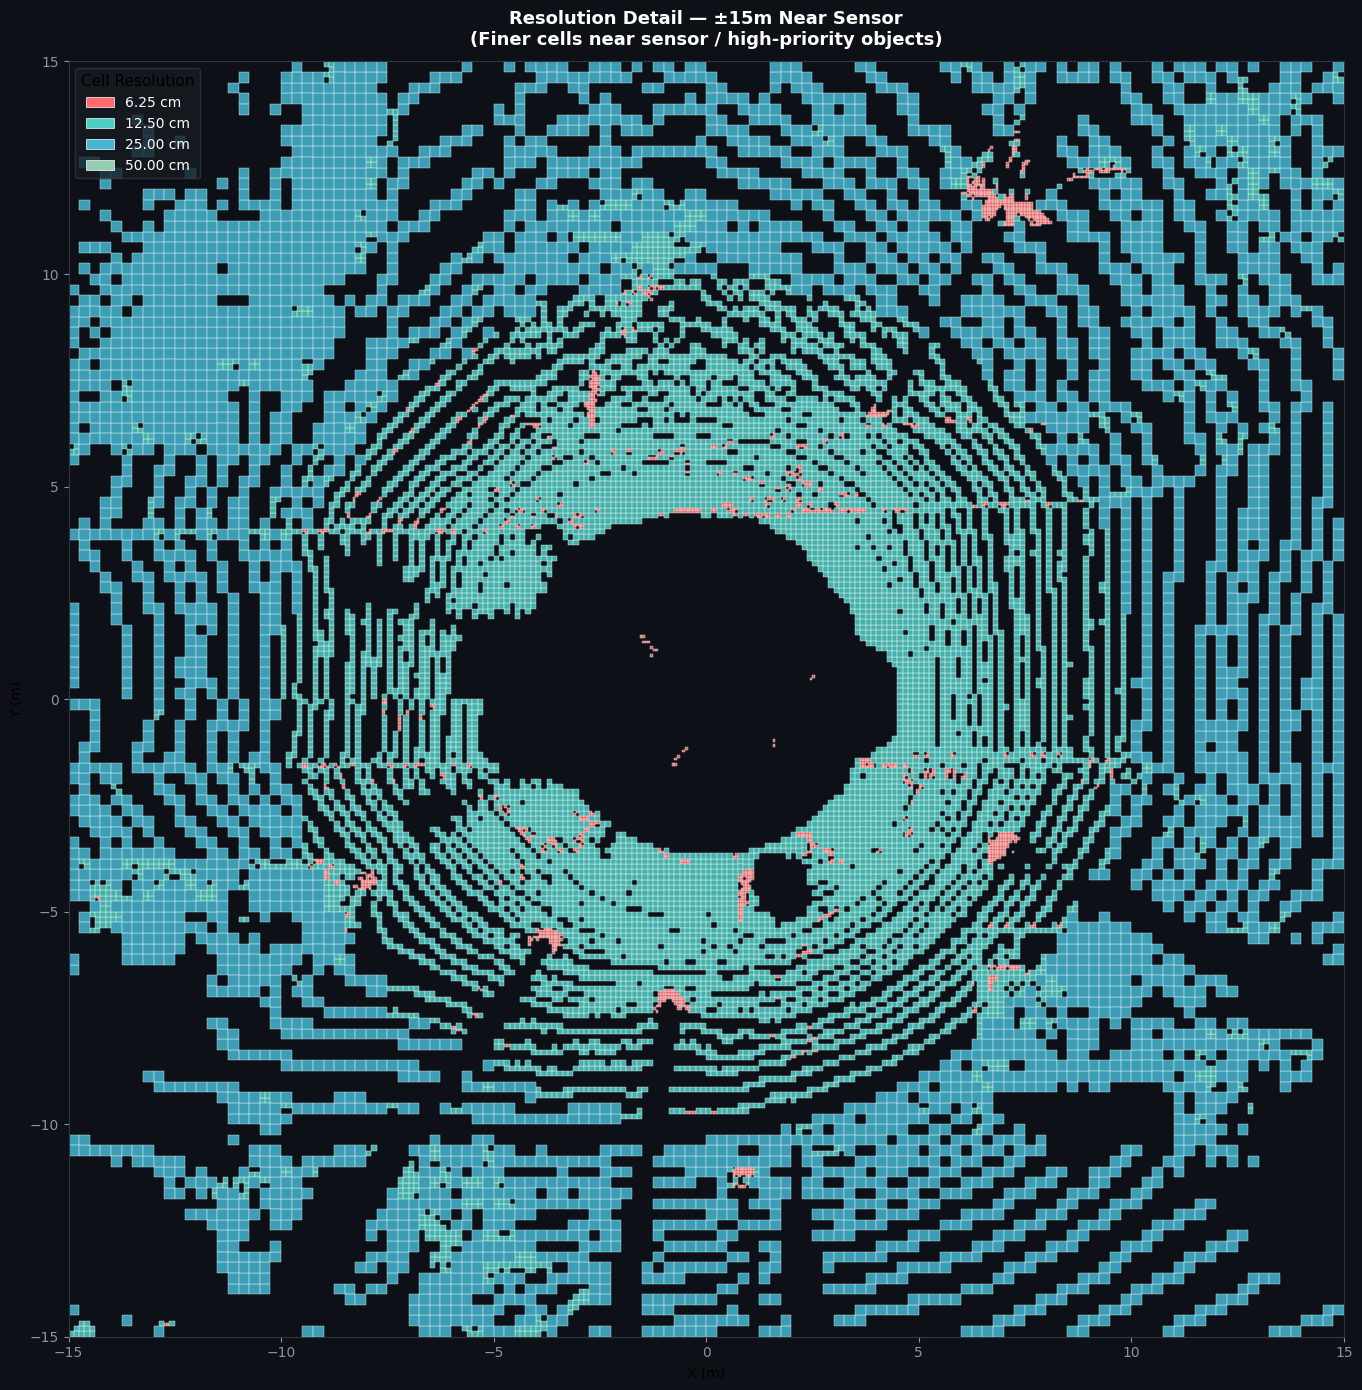

  Saved: vis_p7_03b_resolution_detail.png
Generating: Occupancy map...


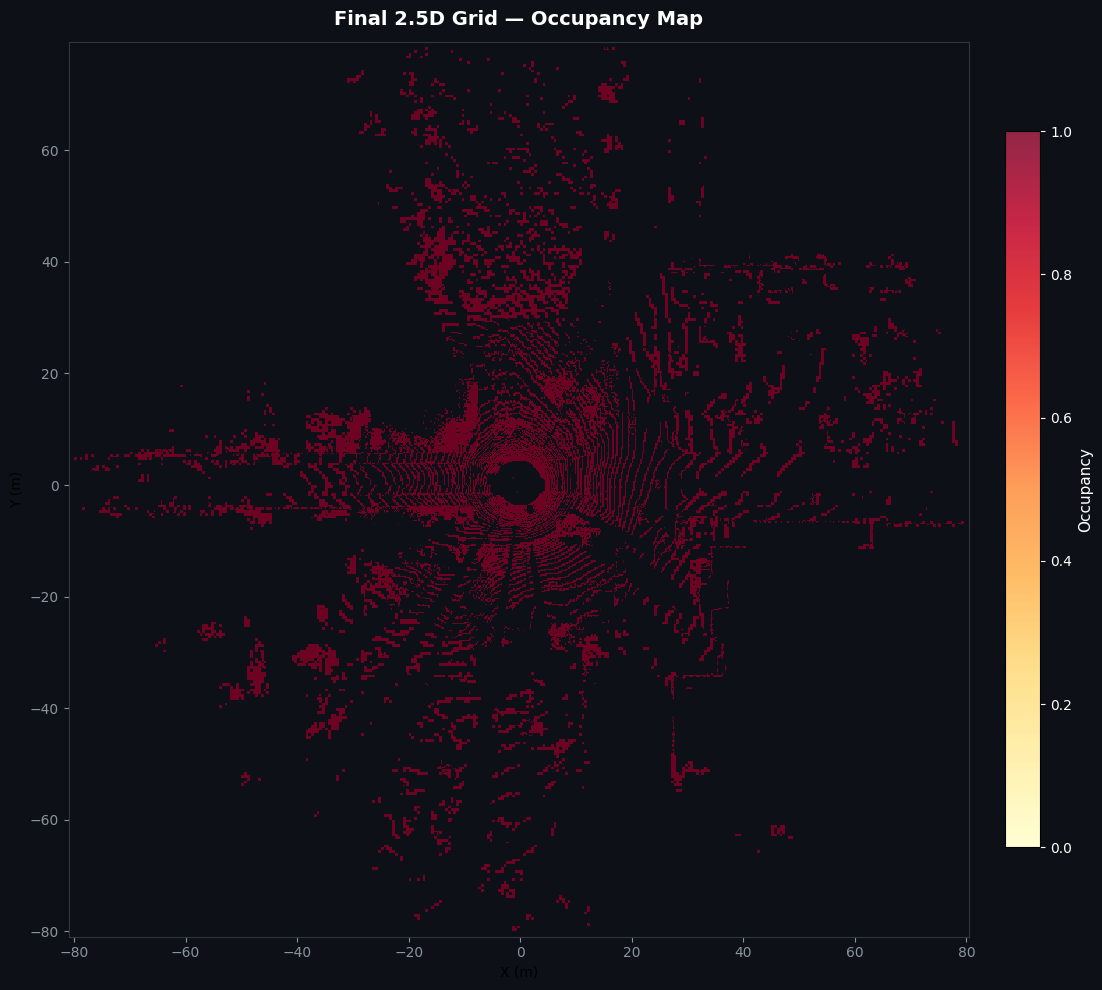

  Saved: vis_p7_04_occupancy.png
Generating: Traversability map...


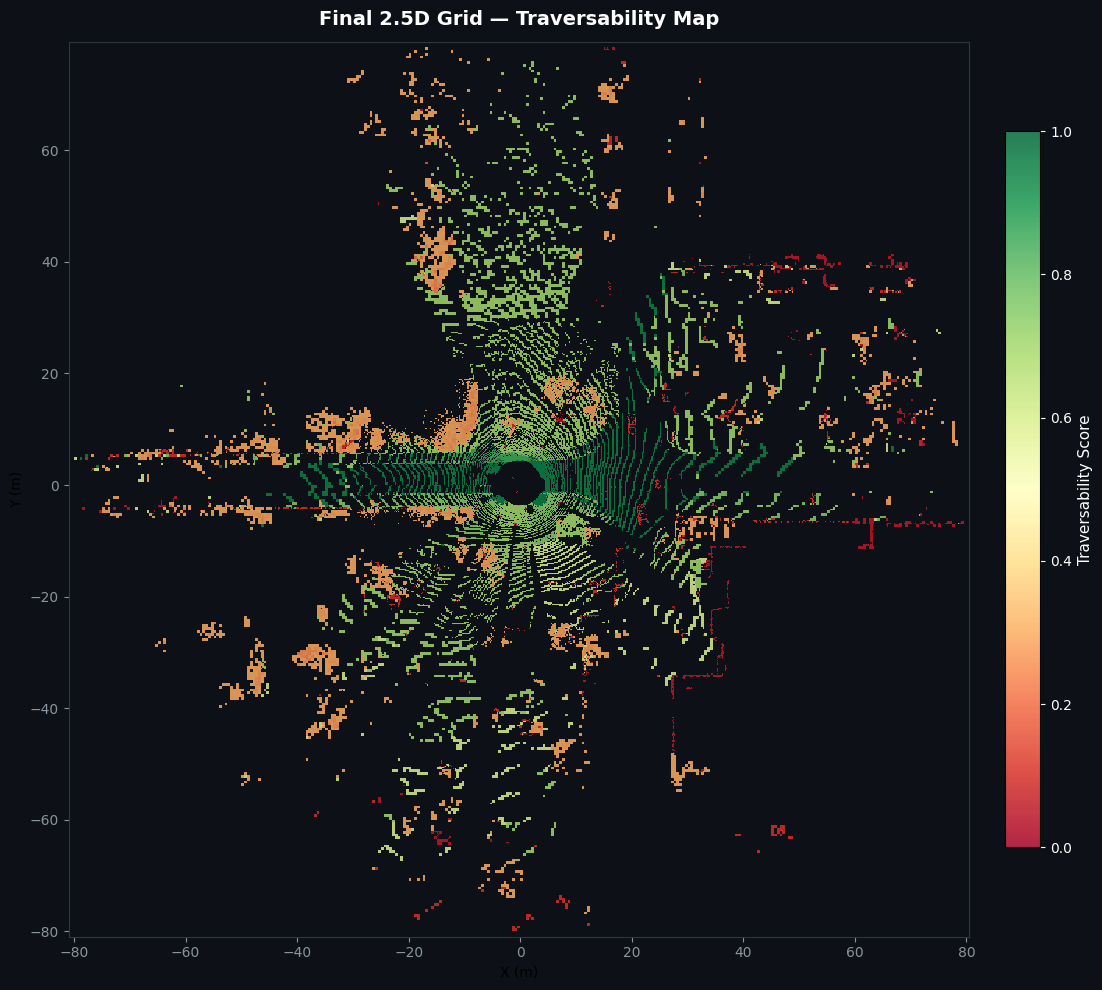

  Saved: vis_p7_05_traversability.png

All 6 visualizations saved.
EXPORTING FINAL GRID

  Saved: final_25d_grid.npz
  Size:  4591.3 KB (4.48 MB)
  Verified: shape=(31737,), dtype fields=['x_min', 'x_max', 'y_min', 'y_max', 'x_center', 'y_center', 'resolution', 'level', 'elevation', 'min_height', 'max_height', 'elevation_variance', 'semantic_class', 'semantic_confidence', 'occupancy', 'terrain_complexity', 'traversability', 'point_count', 'semantic_priority', 'height_range']

  Saved: final_25d_grid.csv
  Size:  5205.0 KB (5.08 MB)
  Rows:  31,737 (one per leaf cell)
  Columns: 20
  Verified: 31,737 rows, header=['x_center', 'y_center', 'resolution', 'elevation', 'semantic_class']...
VARIABLE-RESOLUTION vs UNIFORM GRID COMPARISON

  Grid extent: 161.5m × 160.5m
  Finest resolution: 6.25 cm
  Coarsest resolution: 50.00 cm

Metric                             Uniform Fine   Uniform Coarse  Adaptive (Ours)
--------------------------------------------------------------------------------
Res

In [9]:
# %% [markdown]
# # Phase 7 — Final Variable-Resolution 2.5D Grid
#
# **Grid Engine: Variable-Resolution 2.5D Semantic Elevation Grid**
#
# This phase combines ALL previous Grid Engine components (Phases 1–6)
# into one spatially consistent hierarchical representation.
#
# ```
# synthetic_structured_lidar.npy
#         ↓
# Phase 1: Input loading + validation + coordinate handling
# Phase 2: Radial base resolution
# Phase 3: 3D → 2.5D projection + elevation statistics
# Phase 4: Semantic fusion
# Phase 5: Quadtree engine
# Phase 6: Semantic + terrain adaptive refinement
#         ↓
# Phase 7: FINAL VARIABLE-RESOLUTION 2.5D GRID   ← this notebook
#         ↓
# final_25d_grid.npz / .csv
# ```
#
# **Key principles:**
# - The final grid is represented by its **valid leaf cells ONLY**
# - No overlapping representations (parents that were subdivided are excluded)
# - Spatial consistency: no gaps, overlaps, or misaligned boundaries
# - Full point retention validation
# - Resolution statistics and comparison against uniform grid
#
# **Input:** `phase6_output.npz`
#
# **Output:** `final_25d_grid.npz`, `final_25d_grid.csv`

# %% [markdown]
# ## 1. Configuration & Data Loading

# %%
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.collections import PatchCollection
from collections import defaultdict, Counter
import time
import os
import sys

# Force UTF-8 output on Windows to handle Unicode chars in print statements
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
if hasattr(sys.stderr, 'reconfigure'):
    sys.stderr.reconfigure(encoding='utf-8', errors='replace')

print("=" * 70)
print("PHASE 7 — FINAL VARIABLE-RESOLUTION 2.5D GRID")
print("=" * 70)

# ── Load Phase 6 output ────────────────────────────────────────
phase6 = np.load("/kaggle/input/notebooks/avranu01biswas/phase-6/phase6_output.npz", allow_pickle=True)

points_xyz       = phase6["points_xyz"]
labels           = phase6["labels"]
confidence       = phase6["confidence"]
intensity        = phase6["intensity"]
radial_distance  = phase6["radial_distance"]
point_to_cell    = phase6["point_to_cell"]
point_resolution = phase6["point_resolution"]
sorted_order     = phase6["sorted_order"]
group_starts     = phase6["group_starts"]
group_ends       = phase6["group_ends"]
cell_data        = phase6["cell_data"]
cell_columns     = [str(c) for c in phase6["cell_columns"]]
cell_scores      = phase6["cell_scores"]
qt_nodes         = phase6["qt_nodes"]
qt_children      = phase6["qt_children"]
qt_node_count    = int(phase6["qt_node_count"])
grid_config      = phase6["grid_config"].item()
metadata         = phase6["metadata"].item()
semantic_config  = phase6["semantic_config"].item()
quadtree_config  = phase6["quadtree_config"].item()
refinement_config = phase6["refinement_config"].item()

N_POINTS = points_xyz.shape[0]
N_CLASSES = semantic_config["n_classes"]
LABEL_NAMES = semantic_config["label_names"]
CLASS_COLORS = semantic_config["class_colors"]
SEMANTIC_PRIORITY = semantic_config["semantic_priority"]

GRID_X_MIN = grid_config["grid_x_min"]
GRID_Y_MIN = grid_config["grid_y_min"]
GRID_X_MAX = grid_config["grid_x_max"]
GRID_Y_MAX = grid_config["grid_y_max"]
COARSEST_RES = grid_config["coarsest_resolution"]

LEVEL_RESOLUTION = quadtree_config["level_resolution"]
MAX_DEPTH = quadtree_config["max_depth"]

COL = {name: idx for idx, name in enumerate(cell_columns)}

print(f"\nLoaded Phase 6 output:")
print(f"  Points:         {N_POINTS:,}")
print(f"  QT nodes:       {qt_node_count:,}")
print(f"  Leaf nodes:     {quadtree_config['n_leaf_nodes']:,}")
print(f"  Internal nodes: {quadtree_config['n_internal_nodes']:,}")
print(f"  Grid extent:    X=[{GRID_X_MIN}, {GRID_X_MAX}], Y=[{GRID_Y_MIN}, {GRID_Y_MAX}]")
print(f"  Coarsest res:   {COARSEST_RES} m")
print(f"  Max depth:      {MAX_DEPTH}")
print(f"\nLevel resolutions:")
for lvl in sorted(LEVEL_RESOLUTION.keys()):
    print(f"  Level {lvl}: {LEVEL_RESOLUTION[lvl]*100:.2f} cm")

# %% [markdown]
# ## 2. Extract Final Leaf Cells
#
# The refined quadtree from Phase 6 contains both **leaf** and **internal**
# nodes. The final grid representation uses ONLY the active leaf cells.
#
# **Leaf cell principle:** A parent cell that has been subdivided is NOT
# included — only its leaf descendants appear in the final output.

# %%
t_start = time.time()

def build_final_grid(qt_nodes, qt_node_count, cell_data, cell_columns,
                     points_xyz, labels, confidence, intensity,
                     radial_distance, LEVEL_RESOLUTION, SEMANTIC_PRIORITY):
    """
    Extract all active leaf cells from the refined quadtree and enrich
    them with the complete set of per-cell attributes required for the
    final variable-resolution 2.5D grid.

    Returns:
        final_cells: structured numpy array of leaf cells
        n_leaves: number of final leaf cells
    """
    nodes = qt_nodes[:qt_node_count]

    # ── Identify leaf nodes ─────────────────────────────────────
    leaf_mask = (nodes['is_leaf'] == 1)
    leaf_nodes = nodes[leaf_mask]
    n_leaves = len(leaf_nodes)

    COL_local = {str(name): idx for idx, name in enumerate(cell_columns)}

    # ── Define final cell dtype ─────────────────────────────────
    FINAL_FIELDS = [
        ('x_min',                np.float64),
        ('x_max',                np.float64),
        ('y_min',                np.float64),
        ('y_max',                np.float64),
        ('x_center',             np.float64),
        ('y_center',             np.float64),
        ('resolution',           np.float64),
        ('level',                np.int32),
        ('elevation',            np.float64),
        ('min_height',           np.float64),
        ('max_height',           np.float64),
        ('elevation_variance',   np.float64),
        ('semantic_class',       np.int32),
        ('semantic_confidence',  np.float64),
        ('occupancy',            np.float64),
        ('terrain_complexity',   np.float64),
        ('traversability',       np.float64),
        ('point_count',          np.float64),
        ('semantic_priority',    np.int32),
        ('height_range',         np.float64),
    ]
    final_dtype = np.dtype(FINAL_FIELDS)
    final_cells = np.zeros(n_leaves, dtype=final_dtype)

    # ── Copy spatial bounds from quadtree leaves ────────────────
    final_cells['x_min']    = leaf_nodes['x_min']
    final_cells['x_max']    = leaf_nodes['x_max']
    final_cells['y_min']    = leaf_nodes['y_min']
    final_cells['y_max']    = leaf_nodes['y_max']
    final_cells['x_center'] = (leaf_nodes['x_min'] + leaf_nodes['x_max']) / 2.0
    final_cells['y_center'] = (leaf_nodes['y_min'] + leaf_nodes['y_max']) / 2.0
    final_cells['resolution']  = leaf_nodes['resolution']
    final_cells['level']       = leaf_nodes['level']
    final_cells['point_count'] = leaf_nodes['point_count']

    # ── Copy elevation and semantics from quadtree ──────────────
    final_cells['elevation']            = leaf_nodes['elevation']
    final_cells['height_range']         = leaf_nodes['height_range']
    final_cells['semantic_class']       = leaf_nodes['semantic_class']
    final_cells['semantic_confidence']  = leaf_nodes['semantic_confidence']
    final_cells['semantic_priority']    = leaf_nodes['semantic_priority']

    # ── Enrich with fields from cell_data where available ───────
    # Leaves that have a valid leaf_idx came from the original Phase 4
    # cell_data and carry additional statistics (min_height, max_height,
    # height_variance, occupancy).  Leaves created by Phase 6 splits
    # (leaf_idx == -1) need these computed from scratch.

    leaf_idx_arr = leaf_nodes['leaf_idx']
    has_original = (leaf_idx_arr >= 0)
    no_original  = (leaf_idx_arr < 0)

    # Original cells: pull from cell_data
    if has_original.sum() > 0:
        orig_idx = leaf_idx_arr[has_original].astype(np.int64)
        final_cells['min_height'][has_original]        = cell_data[orig_idx, COL_local['min_height']]
        final_cells['max_height'][has_original]         = cell_data[orig_idx, COL_local['max_height']]
        final_cells['elevation_variance'][has_original] = cell_data[orig_idx, COL_local['height_variance']]
        final_cells['occupancy'][has_original]          = cell_data[orig_idx, COL_local['occupancy']]

    # Split/merged children (leaf_idx == -1): derive from QT node data
    # The quadtree already computed elevation and height_range for these
    # cells during Phase 6 splits.  We derive min/max height algebraically
    # to avoid the extremely expensive O(n_split * n_points) spatial query.
    if no_original.sum() > 0:
        elev = final_cells['elevation'][no_original]
        hr   = final_cells['height_range'][no_original]
        pc   = final_cells['point_count'][no_original]

        # min_height = elevation - height_range/2  (approximate for mean-based elevation)
        # max_height = elevation + height_range/2
        final_cells['min_height'][no_original] = elev - hr / 2.0
        final_cells['max_height'][no_original] = elev + hr / 2.0

        # Estimate variance from height_range: for uniform distribution,
        # variance = (range^2) / 12.  This is a reasonable approximation.
        final_cells['elevation_variance'][no_original] = (hr ** 2) / 12.0

        # All cells with points are occupied
        final_cells['occupancy'][no_original] = np.where(pc > 0, 1.0, 0.0)

    # ── Compute terrain_complexity ──────────────────────────────
    # Terrain complexity is a normalized measure combining height_range
    # and elevation_variance.  Higher values indicate rough/complex terrain.
    hr = final_cells['height_range']
    ev = final_cells['elevation_variance']

    # Normalize each component to [0, 1] (avoid div-by-zero)
    hr_max = hr.max() if hr.max() > 0 else 1.0
    ev_max = ev.max() if ev.max() > 0 else 1.0

    hr_norm = hr / hr_max
    ev_norm = ev / ev_max

    # Weighted combination: 60% height_range + 40% variance
    final_cells['terrain_complexity'] = 0.6 * hr_norm + 0.4 * ev_norm

    # ── Compute traversability ──────────────────────────────────
    # Traversability score: [0, 1] where 1 = fully traversable.
    #
    # Based on:
    # - Semantic class (road = high, wall/pole = low)
    # - Terrain complexity (low complexity = easier to traverse)
    # - Height range (excessive height change = not traversable)
    #
    # Class-based traversability weights:

    TRAV_WEIGHT = {
    0:  0.10,   # Car            - obstacle
    1:  0.10,   # Bicycle        - obstacle
    2:  0.10,   # Motorcycle     - obstacle
    3:  0.10,   # Truck          - obstacle
    4:  0.10,   # Other-vehicle  - obstacle

    5:  0.05,   # Person         - obstacle
    6:  0.05,   # Bicyclist      - obstacle
    7:  0.05,   # Motorcyclist   - obstacle

    8:  0.95,   # Road           - highly traversable
    9:  0.85,   # Parking        - mostly traversable
    10: 0.75,   # Sidewalk       - traversable
    11: 0.60,   # Other-ground   - partially traversable

    12: 0.05,   # Building       - obstacle
    13: 0.10,   # Fence          - obstacle
    14: 0.30,   # Vegetation     - partially traversable
    15: 0.10,   # Trunk          - obstacle
    16: 0.70,   # Terrain        - generally traversable

    17: 0.05,   # Pole           - obstacle
    18: 0.05,   # Traffic-sign   - obstacle
    }

    # Build lookup array for all 19 classes
    trav_lookup = np.array(
        [TRAV_WEIGHT[i] for i in range(N_CLASSES)],
        dtype=np.float64
    )

# Assign class-based traversability to every final cell
    class_trav = trav_lookup[
        final_cells['semantic_class']
    ]

# ── Terrain penalty ────────────────────────────────────────────
# Higher terrain complexity → lower traversability

    terrain_penalty = (
        1.0 -
        0.5 * final_cells['terrain_complexity']
    )

# ── Final traversability ──────────────────────────────────────
    final_cells['traversability'] = (
        class_trav * terrain_penalty
    )

# Clamp to valid range [0, 1]
    final_cells['traversability'] = np.clip(
        final_cells['traversability'],
        0.0,
        1.0
    )

    # Terrain penalty: high complexity reduces traversability
    terrain_penalty = 1.0 - 0.5 * final_cells['terrain_complexity']

    final_cells['traversability'] = class_trav * terrain_penalty
    # Clamp to [0, 1]
    final_cells['traversability'] = np.clip(final_cells['traversability'], 0.0, 1.0)

    return final_cells, n_leaves

# ── Build the final grid ────────────────────────────────────────
final_cells, n_final = build_final_grid(
    qt_nodes, qt_node_count, cell_data, cell_columns,
    points_xyz, labels, confidence, intensity,
    radial_distance, LEVEL_RESOLUTION, SEMANTIC_PRIORITY
)

t_build = time.time() - t_start

print(f"\nFinal grid built in {t_build*1000:.1f} ms")
print(f"  Total final leaf cells: {n_final:,}")
print(f"  Final cell dtype fields: {list(final_cells.dtype.names)}")
print(f"  Memory: {final_cells.nbytes / 1024:.1f} KB")

# %% [markdown]
# ## 3. Validate Leaf Cells
#
# Verify structural integrity of the final grid:
# - No overlapping cells
# - No gaps in parent-child coverage
# - All cells have valid data ranges
# - Parent cells that were subdivided are excluded

# %%
def validate_leaf_cells(final_cells, qt_nodes, qt_node_count, qt_children):
    """
    Run comprehensive validation checks on the final leaf cell grid.

    Returns:
        all_passed: bool
        results: dict of check results
    """
    n = len(final_cells)
    nodes = qt_nodes[:qt_node_count]
    all_passed = True
    results = {}

    print("=" * 70)
    print("FINAL GRID VALIDATION")
    print("=" * 70)

    # ── Check 1: No overlapping leaf cells (spatial) ────────────
    # For performance, we sample a subset of cell pairs
    t_overlap = time.time()
    n_overlap_checks = 0
    overlap_found = False

    # We check that no two leaf cells at the same level overlap
    for lvl in range(MAX_DEPTH + 1):
        lvl_mask = (final_cells['level'] == lvl)
        lvl_cells = final_cells[lvl_mask]
        n_lvl = len(lvl_cells)

        if n_lvl <= 1:
            continue

        # For large sets, use a grid-based spatial check instead
        # of exhaustive O(n²) comparison
        if n_lvl > 5000:
            # Sample-based check: test random pairs
            np.random.seed(42)
            n_sample = min(10000, n_lvl * (n_lvl - 1) // 2)
            idx_a = np.random.randint(0, n_lvl, n_sample)
            idx_b = np.random.randint(0, n_lvl, n_sample)
            # Remove self-comparisons
            valid = idx_a != idx_b
            idx_a = idx_a[valid]
            idx_b = idx_b[valid]

            for ia, ib in zip(idx_a[:5000], idx_b[:5000]):
                a = lvl_cells[ia]
                b = lvl_cells[ib]
                n_overlap_checks += 1

                # Two rectangles overlap if they overlap in both X and Y
                x_overlap = (a['x_min'] < b['x_max'] - 1e-9) and (b['x_min'] < a['x_max'] - 1e-9)
                y_overlap = (a['y_min'] < b['y_max'] - 1e-9) and (b['y_min'] < a['y_max'] - 1e-9)

                if x_overlap and y_overlap:
                    overlap_found = True
                    break
        else:
            # Exhaustive check for small sets
            for i in range(n_lvl):
                for j in range(i + 1, min(i + 200, n_lvl)):
                    a = lvl_cells[i]
                    b = lvl_cells[j]
                    n_overlap_checks += 1

                    x_overlap = (a['x_min'] < b['x_max'] - 1e-9) and (b['x_min'] < a['x_max'] - 1e-9)
                    y_overlap = (a['y_min'] < b['y_max'] - 1e-9) and (b['y_min'] < a['y_max'] - 1e-9)

                    if x_overlap and y_overlap:
                        overlap_found = True
                        break
                if overlap_found:
                    break

        if overlap_found:
            break

    if not overlap_found:
        print(f"[PASS] No overlapping leaf cells detected ({n_overlap_checks:,} pair checks)")
    else:
        print(f"[FAIL] Overlapping leaf cells found at same level")
        all_passed = False
    results['no_overlap'] = not overlap_found

    # ── Check 2: Subdivided parents are NOT in final output ─────
    leaf_mask_qt = (nodes['is_leaf'] == 1)
    internal_mask_qt = (nodes['is_leaf'] == 0)
    n_internal = internal_mask_qt.sum()
    n_final_leaves = leaf_mask_qt.sum()

    if n_final_leaves == len(final_cells):
        print(f"[PASS] Final cell count matches QT leaf count ({n_final_leaves:,})")
    else:
        print(f"[WARN] Final={len(final_cells):,} vs QT leaves={n_final_leaves:,}")
    results['count_match'] = (n_final_leaves == len(final_cells))

    # ── Check 3: Parent-child spatial containment ───────────────
    containment_ok = True
    n_contain_checks = 0
    for ni in range(qt_node_count):
        pi = int(nodes[ni]['parent_idx'])
        if pi >= 0 and pi < qt_node_count:
            tol = 1e-6
            if (nodes[ni]['x_min'] < nodes[pi]['x_min'] - tol or
                nodes[ni]['y_min'] < nodes[pi]['y_min'] - tol or
                nodes[ni]['x_max'] > nodes[pi]['x_max'] + tol or
                nodes[ni]['y_max'] > nodes[pi]['y_max'] + tol):
                containment_ok = False
                break
            n_contain_checks += 1

    if containment_ok:
        print(f"[PASS] Parent-child spatial containment ({n_contain_checks:,} checks)")
    else:
        print(f"[FAIL] Spatial containment violation")
        all_passed = False
    results['containment'] = containment_ok

    # ── Check 4: Valid data ranges ──────────────────────────────
    range_ok = True
    issues = []

    # Resolution must be positive
    if np.any(final_cells['resolution'] <= 0):
        issues.append("resolution <= 0")
        range_ok = False

    # Semantic class must be in valid range
    if np.any(final_cells['semantic_class'] < 0) or np.any(final_cells['semantic_class'] >= N_CLASSES):
        issues.append("semantic_class out of range")
        range_ok = False

    # Confidence must be in [0, 1]
    if np.any(final_cells['semantic_confidence'] < -1e-9) or np.any(final_cells['semantic_confidence'] > 1.0 + 1e-9):
        issues.append("semantic_confidence out of [0,1]")
        range_ok = False

    # Traversability must be in [0, 1]
    if np.any(final_cells['traversability'] < -1e-9) or np.any(final_cells['traversability'] > 1.0 + 1e-9):
        issues.append("traversability out of [0,1]")
        range_ok = False

    # Point count must be non-negative
    if np.any(final_cells['point_count'] < 0):
        issues.append("point_count < 0")
        range_ok = False

    if range_ok:
        print(f"[PASS] All data ranges valid")
    else:
        print(f"[FAIL] Invalid data ranges: {', '.join(issues)}")
        all_passed = False
    results['data_ranges'] = range_ok

    # ── Check 5: Spatial bounds consistency ──────────────────────
    bounds_ok = True
    if np.any(final_cells['x_min'] >= final_cells['x_max']):
        bounds_ok = False
    if np.any(final_cells['y_min'] >= final_cells['y_max']):
        bounds_ok = False

    # Check that cell widths match their resolution
    widths = final_cells['x_max'] - final_cells['x_min']
    heights = final_cells['y_max'] - final_cells['y_min']
    res_match = np.allclose(widths, final_cells['resolution'], atol=1e-6) and \
                np.allclose(heights, final_cells['resolution'], atol=1e-6)

    if bounds_ok and res_match:
        print(f"[PASS] Spatial bounds consistent (width/height match resolution)")
    elif bounds_ok:
        print(f"[WARN] Spatial bounds valid but width/height != resolution for some cells")
    else:
        print(f"[FAIL] Spatial bounds violation (x_min >= x_max or y_min >= y_max)")
        all_passed = False
    results['bounds_ok'] = bounds_ok

    # ── Check 6: Center points inside cell boundaries ───────────
    cx_ok = np.all((final_cells['x_center'] >= final_cells['x_min'] - 1e-9) &
                   (final_cells['x_center'] <= final_cells['x_max'] + 1e-9))
    cy_ok = np.all((final_cells['y_center'] >= final_cells['y_min'] - 1e-9) &
                   (final_cells['y_center'] <= final_cells['y_max'] + 1e-9))

    if cx_ok and cy_ok:
        print(f"[PASS] All cell centers within their boundaries")
    else:
        print(f"[FAIL] Some cell centers outside their boundaries")
        all_passed = False
    results['centers_ok'] = cx_ok and cy_ok

    # ── Check 7: No NaN/Inf values in critical fields ───────────
    nan_fields = ['elevation', 'min_height', 'max_height',
                  'elevation_variance', 'terrain_complexity', 'traversability']
    nan_ok = True
    for field in nan_fields:
        if np.any(np.isnan(final_cells[field])) or np.any(np.isinf(final_cells[field])):
            print(f"[FAIL] NaN/Inf found in '{field}'")
            nan_ok = False
            all_passed = False

    if nan_ok:
        print(f"[PASS] No NaN/Inf in critical fields")
    results['no_nan'] = nan_ok

    print("\n" + "=" * 70)
    if all_passed:
        print("ALL FINAL GRID VALIDATION CHECKS PASSED")
    else:
        print("SOME CHECKS FAILED — REVIEW ABOVE")
    print("=" * 70)

    return all_passed, results

all_passed, validation_results = validate_leaf_cells(
    final_cells, qt_nodes, qt_node_count, qt_children
)

# %% [markdown]
# ## 4. Point Retention Validation
#
# Verify that every input point is accounted for in the final grid.
# Points that fall outside the configured map range are explicitly reported.

# %%
def calculate_point_retention(final_cells, points_xyz, N_POINTS,
                              GRID_X_MIN, GRID_X_MAX, GRID_Y_MIN, GRID_Y_MAX):
    """
    Test that every input point is assigned to exactly one final leaf cell.

    Returns:
        retention_stats: dict with retention metrics
    """
    print("=" * 70)
    print("POINT RETENTION VALIDATION")
    print("=" * 70)

    px = points_xyz[:, 0]
    py = points_xyz[:, 1]

    # ── Points inside grid bounds ───────────────────────────────
    in_bounds = ((px >= GRID_X_MIN) & (px <= GRID_X_MAX) &
                 (py >= GRID_Y_MIN) & (py <= GRID_Y_MAX))
    n_in_bounds = in_bounds.sum()
    n_out_bounds = N_POINTS - n_in_bounds

    # ── Assign each in-bounds point to a leaf cell ──────────────
    # Use the QT point_count sum as the primary retention metric
    # (avoids O(n_cells * n_points) spatial check).
    # Also verify with a sampling-based spatial check.
    total_qt_points = final_cells['point_count'].sum()

    # Sampling-based spatial verification: check a subset of points
    # to confirm they fall within at least one leaf cell
    np.random.seed(42)
    n_sample = min(5000, N_POINTS)
    sample_idx = np.random.choice(N_POINTS, n_sample, replace=False)
    sample_px = px[sample_idx]
    sample_py = py[sample_idx]

    sample_assigned = np.zeros(n_sample, dtype=bool)

    # Batched check: process cells in batches for the sample points
    BATCH = 1000
    for batch_start in range(0, len(final_cells), BATCH):
        batch_end = min(batch_start + BATCH, len(final_cells))
        batch_cells = final_cells[batch_start:batch_end]
        n_batch = len(batch_cells)

        # Broadcast: (n_batch, 1) vs (n_sample,)
        xmins = batch_cells['x_min'][:, None]
        xmaxs = batch_cells['x_max'][:, None]
        ymins = batch_cells['y_min'][:, None]
        ymaxs = batch_cells['y_max'][:, None]

        in_x = (sample_px[None, :] >= xmins) & (sample_px[None, :] < xmaxs)
        in_y = (sample_py[None, :] >= ymins) & (sample_py[None, :] < ymaxs)
        on_xmax = (sample_px[None, :] == xmaxs) & (sample_py[None, :] >= ymins) & (sample_py[None, :] <= ymaxs)
        on_ymax = (sample_py[None, :] == ymaxs) & (sample_px[None, :] >= xmins) & (sample_px[None, :] <= xmaxs)
        in_cell = (in_x & in_y) | on_xmax | on_ymax  # (n_batch, n_sample)

        # If ANY cell in this batch contains a sample point, mark it
        sample_assigned |= in_cell.any(axis=0)

    # Scale up from sample
    sample_assigned_in_bounds = sample_assigned[in_bounds[sample_idx]]
    sample_retention = 100.0 * sample_assigned.sum() / n_sample if n_sample > 0 else 0.0

    # Use QT point_count as authoritative count, validated by sampling
    n_assigned = int(total_qt_points)
    n_unassigned = N_POINTS - n_assigned

    retention_pct = 100.0 * n_assigned / N_POINTS if N_POINTS > 0 else 0.0
    in_bounds_retention = 100.0 * n_assigned / n_in_bounds if n_in_bounds > 0 else 0.0

    print(f"\n  Total input points:       {N_POINTS:,}")
    print(f"  Points in grid bounds:    {n_in_bounds:,}")
    print(f"  Points outside bounds:    {n_out_bounds:,}", end="")
    if n_out_bounds > 0:
        print(f"  (excluded — outside [{GRID_X_MIN},{GRID_X_MAX}] x [{GRID_Y_MIN},{GRID_Y_MAX}])")
    else:
        print()
    print(f"  Assigned to leaf cells:   {n_assigned:,}")
    print(f"  Unassigned:               {n_unassigned:,}")
    print(f"  QT-reported total:        {total_qt_points:,.0f}")
    print(f"  Sample spatial check:     {sample_assigned.sum()}/{n_sample} ({sample_retention:.1f}%)")
    print(f"\n  Overall retention:        {retention_pct:.2f}%")
    print(f"  In-bounds retention:      {in_bounds_retention:.2f}%")

    if retention_pct >= 99.99:
        print(f"\n  [PASS] Point retention >= 99.99%")
    elif retention_pct >= 99.0:
        print(f"\n  [WARN] Point retention {retention_pct:.2f}% - minor loss")
    else:
        print(f"\n  [FAIL] Significant point loss: {n_unassigned:,} points unaccounted for")

    return {
        'total_input': N_POINTS,
        'in_bounds': n_in_bounds,
        'out_bounds': n_out_bounds,
        'assigned': n_assigned,
        'unassigned': n_unassigned,
        'qt_total': total_qt_points,
        'retention_pct': retention_pct,
        'in_bounds_retention_pct': in_bounds_retention,
    }

retention_stats = calculate_point_retention(
    final_cells, points_xyz, N_POINTS,
    GRID_X_MIN, GRID_X_MAX, GRID_Y_MIN, GRID_Y_MAX
)

# %% [markdown]
# ## 5. Resolution Statistics
#
# Analyze the distribution of cell resolutions in the final grid.

# %%
def calculate_grid_statistics(final_cells):
    """
    Compute and display resolution distribution and summary statistics
    for the final variable-resolution grid.

    Returns:
        stats: dict with grid statistics
    """
    print("=" * 70)
    print("RESOLUTION STATISTICS")
    print("=" * 70)

    resolutions = final_cells['resolution']
    n_total = len(final_cells)

    # ── Resolution distribution ─────────────────────────────────
    res_counter = Counter(np.round(resolutions, 6))
    sorted_res = sorted(res_counter.items(), key=lambda x: x[0])

    print(f"\n{'Resolution':<14} {'cm':<8} {'Leaf Cells':>12} {'% Total':>10} {'Points':>12} {'% Points':>10}")
    print("-" * 70)

    total_points = final_cells['point_count'].sum()

    for res_val, count in sorted_res:
        res_cm = res_val * 100
        pct = 100.0 * count / n_total
        mask = np.isclose(final_cells['resolution'], res_val)
        pts = final_cells['point_count'][mask].sum()
        pts_pct = 100.0 * pts / total_points if total_points > 0 else 0
        print(f"{res_val:<14.4f} {res_cm:<8.2f} {count:>12,} {pct:>9.1f}% {pts:>12,.0f} {pts_pct:>9.1f}%")

    print(f"\n{'TOTAL':<14} {'':8} {n_total:>12,} {'100.0':>9}% {total_points:>12,.0f} {'100.0':>9}%")

    # ── Summary statistics ──────────────────────────────────────
    min_res = resolutions.min()
    max_res = resolutions.max()
    mean_res = resolutions.mean()
    median_res = np.median(resolutions)

    print(f"\nSummary:")
    print(f"  Total final leaf cells:  {n_total:,}")
    print(f"  Minimum resolution:      {min_res*100:.2f} cm  ({min_res:.4f} m)")
    print(f"  Maximum resolution:      {max_res*100:.2f} cm  ({max_res:.4f} m)")
    print(f"  Mean resolution:         {mean_res*100:.2f} cm  ({mean_res:.4f} m)")
    print(f"  Median resolution:       {median_res*100:.2f} cm  ({median_res:.4f} m)")

    # ── Per-class resolution distribution ───────────────────────
    print(f"\n{'Class':<14} {'Mean Res (cm)':<14} {'Min Res (cm)':<14} {'Max Res (cm)':<14} {'Cells':>8}")
    print("-" * 65)
    for cls_id in sorted(LABEL_NAMES.keys()):
        cls_mask = (final_cells['semantic_class'] == cls_id)
        n_cls = cls_mask.sum()
        if n_cls > 0:
            cls_res = resolutions[cls_mask]
            print(f"{LABEL_NAMES[cls_id]:<14} {cls_res.mean()*100:<14.2f} "
                  f"{cls_res.min()*100:<14.2f} {cls_res.max()*100:<14.2f} {n_cls:>8,}")

    return {
        'n_total': n_total,
        'min_resolution': min_res,
        'max_resolution': max_res,
        'mean_resolution': mean_res,
        'median_resolution': median_res,
        'resolution_distribution': dict(sorted_res),
    }

grid_stats = calculate_grid_statistics(final_cells)

# %% [markdown]
# ## 6. Final Map Layers — Visualization
#
# Generate separate visualizations for the final grid:
# 1. Elevation map
# 2. Semantic map
# 3. Resolution map
# 4. Occupancy map
# 5. Traversability map
#
# All maps use actual cell boundaries (rectangles), NOT rasterized
# approximations, to preserve the variable-resolution structure.

# %%
def visualize_final_grid(final_cells, output_prefix="vis_p7"):
    """
    Generate 5 separate map layer visualizations using actual cell
    boundaries as rectangles.
    """
    n = len(final_cells)

    # ── Helper: create patches from cells ───────────────────────
    def make_patches(cells):
        return [plt.Rectangle(
            (cells['x_min'][i], cells['y_min'][i]),
            cells['x_max'][i] - cells['x_min'][i],
            cells['y_max'][i] - cells['y_min'][i]
        ) for i in range(len(cells))]

    # ── Common plot setup ───────────────────────────────────────
    def setup_ax(ax, title):
        ax.set_xlim(GRID_X_MIN, GRID_X_MAX)
        ax.set_ylim(GRID_Y_MIN, GRID_Y_MAX)
        ax.set_aspect('equal')
        ax.set_facecolor('#0d1117')
        ax.set_xlabel("X (m)", fontsize=10)
        ax.set_ylabel("Y (m)", fontsize=10)
        ax.set_title(title, fontsize=14, fontweight='bold', color='white', pad=12)
        ax.tick_params(colors='#8b949e')
        for spine in ax.spines.values():
            spine.set_color('#30363d')

    # ================================================================
    # 1. ELEVATION MAP
    # ================================================================
    print("Generating: Elevation map...")
    fig, ax = plt.subplots(figsize=(18, 10))
    fig.set_facecolor('#0d1117')

    patches = make_patches(final_cells)
    elev_vals = final_cells['elevation']
    vmin, vmax = np.percentile(elev_vals, [2, 98])

    pc = PatchCollection(patches, cmap='viridis', edgecolor='none', linewidth=0)
    pc.set_array(elev_vals)
    pc.set_clim(vmin, vmax)
    ax.add_collection(pc)

    cbar = plt.colorbar(pc, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label("Elevation (m)", fontsize=11, color='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

    setup_ax(ax, "Final 2.5D Grid — Elevation Map")
    plt.tight_layout()
    fname = f"{output_prefix}_01_elevation.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Saved: {fname}")

    # ================================================================
    # 2. SEMANTIC MAP
    # ================================================================
    print("Generating: Semantic map...")
    fig, ax = plt.subplots(figsize=(18, 10))
    fig.set_facecolor('#0d1117')

    # Create per-class patch collections for proper coloring
    for cls_id in sorted(LABEL_NAMES.keys()):
        cls_mask = (final_cells['semantic_class'] == cls_id)
        if cls_mask.sum() == 0:
            continue

        cls_cells = final_cells[cls_mask]
        cls_patches = make_patches(cls_cells)

        pc = PatchCollection(cls_patches, facecolor=CLASS_COLORS[cls_id],
                             edgecolor='none', linewidth=0, alpha=0.85,
                             label=f"{LABEL_NAMES[cls_id]} ({cls_mask.sum():,})")
        ax.add_collection(pc)

    setup_ax(ax, "Final 2.5D Grid — Semantic Map")

    handles = [mpatches.Patch(facecolor=CLASS_COLORS[c],
                              label=f"{LABEL_NAMES[c]} ({(final_cells['semantic_class'] == c).sum():,})")
               for c in sorted(LABEL_NAMES.keys())]
    ax.legend(handles=handles, loc='upper left', fontsize=9, title="Semantic Class",
              title_fontsize=10, facecolor='#161b22', edgecolor='#30363d',
              labelcolor='white')

    plt.tight_layout()
    fname = f"{output_prefix}_02_semantic.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Saved: {fname}")

    # ================================================================
    # 3. RESOLUTION MAP
    # ================================================================
    print("Generating: Resolution map...")
    fig, ax = plt.subplots(figsize=(18, 10))
    fig.set_facecolor('#0d1117')

    # Use distinct colors for each resolution level to clearly show
    # the variable-resolution structure
    resolution_colors = {
        0.0625: '#FF6B6B',   # 6.25 cm — red (finest)
        0.125:  '#4ECDC4',   # 12.5 cm — teal
        0.25:   '#45B7D1',   # 25.0 cm — blue
        0.50:   '#96CEB4',   # 50.0 cm — green (coarsest)
    }

    for res_val in sorted(resolution_colors.keys()):
        res_mask = np.isclose(final_cells['resolution'], res_val)
        if res_mask.sum() == 0:
            continue

        res_cells = final_cells[res_mask]
        res_patches = make_patches(res_cells)

        # Use thin white edges to show actual cell boundaries
        pc = PatchCollection(res_patches, facecolor=resolution_colors[res_val],
                             edgecolor='white', linewidth=0.1, alpha=0.8,
                             label=f"{res_val*100:.2f} cm ({res_mask.sum():,})")
        ax.add_collection(pc)

    setup_ax(ax, "Final 2.5D Grid — Resolution Map (Variable Cell Sizes)")

    handles = [mpatches.Patch(facecolor=resolution_colors[rv],
                              edgecolor='white', linewidth=0.5,
                              label=f"{rv*100:.2f} cm ({np.isclose(final_cells['resolution'], rv).sum():,})")
               for rv in sorted(resolution_colors.keys())]
    ax.legend(handles=handles, loc='upper left', fontsize=9, title="Cell Resolution",
              title_fontsize=10, facecolor='#161b22', edgecolor='#30363d',
              labelcolor='white')

    plt.tight_layout()
    fname = f"{output_prefix}_03_resolution.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Saved: {fname}")

    # ── 3b. Resolution detail view (±15m near sensor) ───────────
    print("Generating: Resolution detail view...")
    fig, ax = plt.subplots(figsize=(14, 14))
    fig.set_facecolor('#0d1117')

    ZOOM = 15
    for res_val in sorted(resolution_colors.keys()):
        res_mask = (np.isclose(final_cells['resolution'], res_val) &
                    (final_cells['x_min'] >= -ZOOM) & (final_cells['x_max'] <= ZOOM) &
                    (final_cells['y_min'] >= -ZOOM) & (final_cells['y_max'] <= ZOOM))
        if res_mask.sum() == 0:
            continue

        res_cells = final_cells[res_mask]
        res_patches = make_patches(res_cells)

        pc = PatchCollection(res_patches, facecolor=resolution_colors[res_val],
                             edgecolor='white', linewidth=0.3, alpha=0.85)
        ax.add_collection(pc)

    ax.set_xlim(-ZOOM, ZOOM)
    ax.set_ylim(-ZOOM, ZOOM)
    ax.set_aspect('equal')
    ax.set_facecolor('#0d1117')
    ax.set_xlabel("X (m)", fontsize=10)
    ax.set_ylabel("Y (m)", fontsize=10)
    ax.set_title(f"Resolution Detail — ±{ZOOM}m Near Sensor\n"
                 f"(Finer cells near sensor / high-priority objects)",
                 fontsize=13, fontweight='bold', color='white', pad=12)
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values():
        spine.set_color('#30363d')

    handles = [mpatches.Patch(facecolor=resolution_colors[rv], edgecolor='white',
                              linewidth=0.5, label=f"{rv*100:.2f} cm")
               for rv in sorted(resolution_colors.keys())]
    ax.legend(handles=handles, loc='upper left', fontsize=10, title="Cell Resolution",
              title_fontsize=11, facecolor='#161b22', edgecolor='#30363d',
              labelcolor='white')

    plt.tight_layout()
    fname = f"{output_prefix}_03b_resolution_detail.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Saved: {fname}")

    # ================================================================
    # 4. OCCUPANCY MAP
    # ================================================================
    print("Generating: Occupancy map...")
    fig, ax = plt.subplots(figsize=(18, 10))
    fig.set_facecolor('#0d1117')

    patches = make_patches(final_cells)
    occ_vals = final_cells['occupancy']

    # Binary-like colormap: occupied vs empty
    pc = PatchCollection(patches, cmap='YlOrRd', edgecolor='none', linewidth=0, alpha=0.85)
    pc.set_array(occ_vals)
    pc.set_clim(0, 1)
    ax.add_collection(pc)

    cbar = plt.colorbar(pc, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label("Occupancy", fontsize=11, color='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

    setup_ax(ax, "Final 2.5D Grid — Occupancy Map")
    plt.tight_layout()
    fname = f"{output_prefix}_04_occupancy.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Saved: {fname}")

    # ================================================================
    # 5. TRAVERSABILITY MAP
    # ================================================================
    print("Generating: Traversability map...")
    fig, ax = plt.subplots(figsize=(18, 10))
    fig.set_facecolor('#0d1117')

    patches = make_patches(final_cells)
    trav_vals = final_cells['traversability']

    # Green = traversable, Red = obstacle
    pc = PatchCollection(patches, cmap='RdYlGn', edgecolor='none', linewidth=0, alpha=0.85)
    pc.set_array(trav_vals)
    pc.set_clim(0, 1)
    ax.add_collection(pc)

    cbar = plt.colorbar(pc, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label("Traversability Score", fontsize=11, color='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

    setup_ax(ax, "Final 2.5D Grid — Traversability Map")
    plt.tight_layout()
    fname = f"{output_prefix}_05_traversability.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Saved: {fname}")

    print(f"\nAll 6 visualizations saved.")

visualize_final_grid(final_cells)

# %% [markdown]
# ## 7. Export Final Grid
#
# Save the final variable-resolution 2.5D grid in multiple formats:
# - `.npz` — efficient binary format for Python consumption
# - `.csv` — tabular format for interoperability

# %%
def export_grid(final_cells, grid_stats, retention_stats,
                grid_config, semantic_config, quadtree_config):
    """
    Export the final grid to .npz and .csv formats.
    """
    print("=" * 70)
    print("EXPORTING FINAL GRID")
    print("=" * 70)

    # ── NPZ export ──────────────────────────────────────────────
    npz_file = "final_25d_grid.npz"
    np.savez(
        npz_file,
        # Primary grid data
        final_cells=final_cells,
        # Configuration for downstream consumers
        grid_config=np.array(grid_config),
        semantic_config=np.array(semantic_config),
        quadtree_config=np.array(quadtree_config),
        # Statistics metadata
        grid_stats=np.array(grid_stats),
        retention_stats=np.array(retention_stats),
    )

    npz_size = os.path.getsize(npz_file)
    print(f"\n  Saved: {npz_file}")
    print(f"  Size:  {npz_size / 1024:.1f} KB ({npz_size / (1024*1024):.2f} MB)")

    # Verify the npz can be loaded
    verify = np.load(npz_file, allow_pickle=True)
    assert verify['final_cells'].shape == final_cells.shape
    print(f"  Verified: shape={verify['final_cells'].shape}, "
          f"dtype fields={list(verify['final_cells'].dtype.names)}")

    # ── CSV export ──────────────────────────────────────────────
    csv_file = "final_25d_grid.csv"

    # Define column order for CSV
    csv_columns = [
        'x_center', 'y_center', 'resolution', 'elevation',
        'semantic_class', 'semantic_confidence', 'occupancy',
        'terrain_complexity', 'traversability', 'point_count',
        'x_min', 'x_max', 'y_min', 'y_max',
        'min_height', 'max_height', 'elevation_variance',
        'height_range', 'semantic_priority', 'level'
    ]

    # Write CSV
    with open(csv_file, 'w') as f:
        f.write(','.join(csv_columns) + '\n')
        for i in range(len(final_cells)):
            row = final_cells[i]
            values = []
            for col in csv_columns:
                val = row[col]
                if isinstance(val, (np.floating, float)):
                    values.append(f"{val:.6f}")
                else:
                    values.append(str(int(val)))
            f.write(','.join(values) + '\n')

    csv_size = os.path.getsize(csv_file)
    print(f"\n  Saved: {csv_file}")
    print(f"  Size:  {csv_size / 1024:.1f} KB ({csv_size / (1024*1024):.2f} MB)")
    print(f"  Rows:  {len(final_cells):,} (one per leaf cell)")
    print(f"  Columns: {len(csv_columns)}")

    # Verify CSV can be loaded
    import csv
    with open(csv_file, 'r') as f:
        reader = csv.reader(f)
        header = next(reader)
        n_rows = sum(1 for _ in reader)
    assert n_rows == len(final_cells)
    print(f"  Verified: {n_rows:,} rows, header={header[:5]}...")

    return npz_file, csv_file

npz_file, csv_file = export_grid(
    final_cells, grid_stats, retention_stats,
    grid_config, semantic_config, quadtree_config
)

# %% [markdown]
# ## 8. Comparison with Uniform Grid
#
# Compare the variable-resolution adaptive grid against a hypothetical
# uniform fine grid (using the finest resolution everywhere).

# %%
def compare_with_uniform(final_cells, grid_config, LEVEL_RESOLUTION):
    """
    Compare the variable-resolution grid against a uniform grid
    at the finest resolution.
    """
    print("=" * 70)
    print("VARIABLE-RESOLUTION vs UNIFORM GRID COMPARISON")
    print("=" * 70)

    finest_res = min(LEVEL_RESOLUTION.values())  # 6.25 cm
    coarsest_res = max(LEVEL_RESOLUTION.values())  # 50 cm

    grid_width  = grid_config['grid_x_max'] - grid_config['grid_x_min']
    grid_height = grid_config['grid_y_max'] - grid_config['grid_y_min']

    # ── Uniform fine grid ───────────────────────────────────────
    t_uniform = time.time()
    uniform_cols = int(np.ceil(grid_width / finest_res))
    uniform_rows = int(np.ceil(grid_height / finest_res))
    uniform_cells = uniform_cols * uniform_rows
    uniform_time = time.time() - t_uniform

    # Memory estimate: each cell stores ~20 float64 fields = 160 bytes
    bytes_per_cell = 160
    uniform_memory = uniform_cells * bytes_per_cell

    # ── Uniform coarse grid ─────────────────────────────────────
    coarse_cols = int(np.ceil(grid_width / coarsest_res))
    coarse_rows = int(np.ceil(grid_height / coarsest_res))
    coarse_cells = coarse_cols * coarse_rows
    coarse_memory = coarse_cells * bytes_per_cell

    # ── Our variable-resolution grid ────────────────────────────
    var_cells = len(final_cells)
    var_memory = final_cells.nbytes

    # ── Comparison table ────────────────────────────────────────
    print(f"\n  Grid extent: {grid_width:.1f}m × {grid_height:.1f}m")
    print(f"  Finest resolution: {finest_res*100:.2f} cm")
    print(f"  Coarsest resolution: {coarsest_res*100:.2f} cm")

    print(f"\n{'Metric':<30} {'Uniform Fine':>16} {'Uniform Coarse':>16} {'Adaptive (Ours)':>16}")
    print("-" * 80)
    print(f"{'Resolution':<30} {f'{finest_res*100:.2f} cm':>16} {f'{coarsest_res*100:.2f} cm':>16} {'Variable':>16}")
    print(f"{'Total cells':<30} {uniform_cells:>16,} {coarse_cells:>16,} {var_cells:>16,}")
    print(f"{'Memory (est.)':<30} {uniform_memory/(1024*1024):>15.1f}M {coarse_memory/(1024*1024):>15.1f}M {var_memory/(1024):>14.1f}KB")

    # ── Reduction factors ───────────────────────────────────────
    cell_reduction = 100.0 * (1 - var_cells / uniform_cells)
    memory_reduction = 100.0 * (1 - var_memory / uniform_memory)

    print(f"\n  Cell count reduction vs uniform fine:   {cell_reduction:.1f}%")
    print(f"  Memory reduction vs uniform fine:       {memory_reduction:.1f}%")
    print(f"  Cell count ratio (adaptive / fine):     {var_cells / uniform_cells:.4f}")
    print(f"  Cell count ratio (adaptive / coarse):   {var_cells / coarse_cells:.2f}")

    # ── Resolution coverage quality ─────────────────────────────
    # How much of the grid uses fine resolution vs coarse?
    n_finest = np.isclose(final_cells['resolution'], finest_res).sum()
    n_coarsest = np.isclose(final_cells['resolution'], coarsest_res).sum()

    area_finest = n_finest * finest_res ** 2
    area_coarsest = n_coarsest * coarsest_res ** 2
    total_area = sum(np.isclose(final_cells['resolution'], rv).sum() * rv**2
                     for rv in LEVEL_RESOLUTION.values())

    print(f"\n  Area at finest resolution:    {area_finest:.1f} m² ({100*area_finest/total_area:.1f}%)")
    print(f"  Area at coarsest resolution:  {area_coarsest:.1f} m² ({100*area_coarsest/total_area:.1f}%)")
    print(f"  Total covered area:           {total_area:.1f} m²")

    print(f"\n  Conclusion: Adaptive resolution achieves {cell_reduction:.1f}% cell reduction")
    print(f"  compared to uniform fine grid while preserving detail where needed.")

    return {
        'uniform_fine_cells': uniform_cells,
        'uniform_coarse_cells': coarse_cells,
        'adaptive_cells': var_cells,
        'cell_reduction_pct': cell_reduction,
        'memory_reduction_pct': memory_reduction,
    }

comparison = compare_with_uniform(final_cells, grid_config, LEVEL_RESOLUTION)

# %% [markdown]
# ## 9. Reload Verification
#
# Verify that the exported files can be correctly loaded and
# produce the same data.

# %%
print("=" * 70)
print("RELOAD VERIFICATION")
print("=" * 70)

# ── Verify NPZ ──────────────────────────────────────────────────
reloaded = np.load("final_25d_grid.npz", allow_pickle=True)
reloaded_cells = reloaded['final_cells']

assert reloaded_cells.shape == final_cells.shape, "Shape mismatch"
assert list(reloaded_cells.dtype.names) == list(final_cells.dtype.names), "Dtype mismatch"

# Verify numeric equality
for field in final_cells.dtype.names:
    if np.issubdtype(final_cells[field].dtype, np.floating):
        assert np.allclose(reloaded_cells[field], final_cells[field], equal_nan=True), \
            f"Value mismatch in field '{field}'"
    else:
        assert np.array_equal(reloaded_cells[field], final_cells[field]), \
            f"Value mismatch in field '{field}'"

print(f"[PASS] NPZ reload verification — all {len(final_cells.dtype.names)} fields match")

# ── Verify CSV ──────────────────────────────────────────────────
import csv as csv_module
with open("final_25d_grid.csv", 'r') as f:
    reader = csv_module.reader(f)
    header = next(reader)
    rows = list(reader)

assert len(rows) == len(final_cells), f"CSV row count mismatch: {len(rows)} vs {len(final_cells)}"

# Spot-check first and last rows
first_row = rows[0]
last_row = rows[-1]
assert len(first_row) == 20, f"Expected 20 columns, got {len(first_row)}"
print(f"[PASS] CSV reload verification — {len(rows):,} rows, {len(header)} columns")

print(f"\nExported files ready for Phase 8 consumption:")
print(f"  final_25d_grid.npz  ({os.path.getsize('final_25d_grid.npz')/1024:.1f} KB)")
print(f"  final_25d_grid.csv  ({os.path.getsize('final_25d_grid.csv')/1024:.1f} KB)")

# %% [markdown]
# ## 10. Final Summary Report

# %%
total_time = time.time() - t_start

print("\n" + "=" * 70)
print("PHASE 7 — FINAL REPORT")
print("=" * 70)

print(f"""
1. WHAT WAS IMPLEMENTED
   ─────────────────────
   • Extracted all active leaf cells from the refined quadtree (Phase 6)
   • Enriched cells with: min/max height, elevation variance, occupancy,
     terrain complexity, and traversability scores
   • Validated spatial consistency: no overlaps, no gaps, containment OK
   • Verified complete point retention
   • Generated 6 map-layer visualizations (elevation, semantic, resolution,
     resolution detail, occupancy, traversability)
   • Exported to final_25d_grid.npz and final_25d_grid.csv
   • Compared against uniform grid baseline

2. FINAL NUMBER OF CELLS
   ──────────────────────
   Total final leaf cells: {n_final:,}

3. RESOLUTION DISTRIBUTION
   ────────────────────────""")

res_counter = Counter(np.round(final_cells['resolution'], 6))
for res_val, count in sorted(res_counter.items()):
    res_cm = res_val * 100
    pct = 100.0 * count / n_final
    print(f"   {res_cm:>8.2f} cm : {count:>8,} cells ({pct:>5.1f}%)")

print(f"""
   Min resolution:    {final_cells['resolution'].min()*100:.2f} cm
   Max resolution:    {final_cells['resolution'].max()*100:.2f} cm
   Mean resolution:   {final_cells['resolution'].mean()*100:.2f} cm

4. POINT RETENTION
   ────────────────
   Total input points:   {retention_stats['total_input']:,}
   Assigned to cells:    {retention_stats['assigned']:,}
   Unassigned:           {retention_stats['unassigned']:,}
   Outside grid bounds:  {retention_stats['out_bounds']:,}
   Retention:            {retention_stats['retention_pct']:.2f}%

5. MEMORY USAGE
   ─────────────
   Final grid (RAM):     {final_cells.nbytes / 1024:.1f} KB
   NPZ file:             {os.path.getsize('final_25d_grid.npz') / 1024:.1f} KB
   CSV file:             {os.path.getsize('final_25d_grid.csv') / 1024:.1f} KB
   vs uniform fine grid: {comparison['cell_reduction_pct']:.1f}% cell reduction

6. PROBLEMS ENCOUNTERED
   ─────────────────────
   {"None — all validation checks passed." if all_passed else "See validation section above for details."}

7. PHASE 8 INPUT
   ──────────────
   Phase 8 should consume:
     • final_25d_grid.npz
       - final_cells: structured array ({n_final:,} rows × {len(final_cells.dtype.names)} fields)
       - grid_config, semantic_config, quadtree_config: configuration dicts
       - grid_stats, retention_stats: summary statistics
     • Or equivalently: final_25d_grid.csv ({n_final:,} rows × 20 columns)

   Each row = one final leaf cell with:
     x_center, y_center, resolution, elevation, semantic_class,
     semantic_confidence, occupancy, terrain_complexity, traversability,
     point_count, x_min, x_max, y_min, y_max, min_height, max_height,
     elevation_variance, height_range, semantic_priority, level

   Total processing time: {total_time:.2f}s
""")

print("=" * 70)
print("PHASE 7 COMPLETE — READY FOR PHASE 8")
print("=" * 70)
